In [ ]:
!pip install wheel
!pip install scikit-learn matplotlib numpy tensorflowg


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Training samples: (10000, 784)
Testing samples: (10000, 784)
k=1  accuracy=0.9393
k=2  accuracy=0.9307
k=3  accuracy=0.9395
k=4  accuracy=0.9405
k=5  accuracy=0.9377
k=6  accuracy=0.9363
k=7  accuracy=0.9360
k=8  accuracy=0.9344
k=9  accuracy=0.9345

Best k: 4
Model trained successfully!

Accuracy: 0.9442

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       980
           1       0.91      0.99      0.95      1135
           2       0.97      0.92      0.95      1032
           3       0.92      0.95      0.94      1010
           4       0.96      0.95      0.95       982
           5       0.95      0.93      0.94       892
           6       0.96      0.97      0.97       958
           7       0.93      0.94      0.93      1028
           8       0.98      0.87      0.92       974
           9       0.94      0.92      0.93      1009

    accuracy                           0.94     10000
   macro avg       

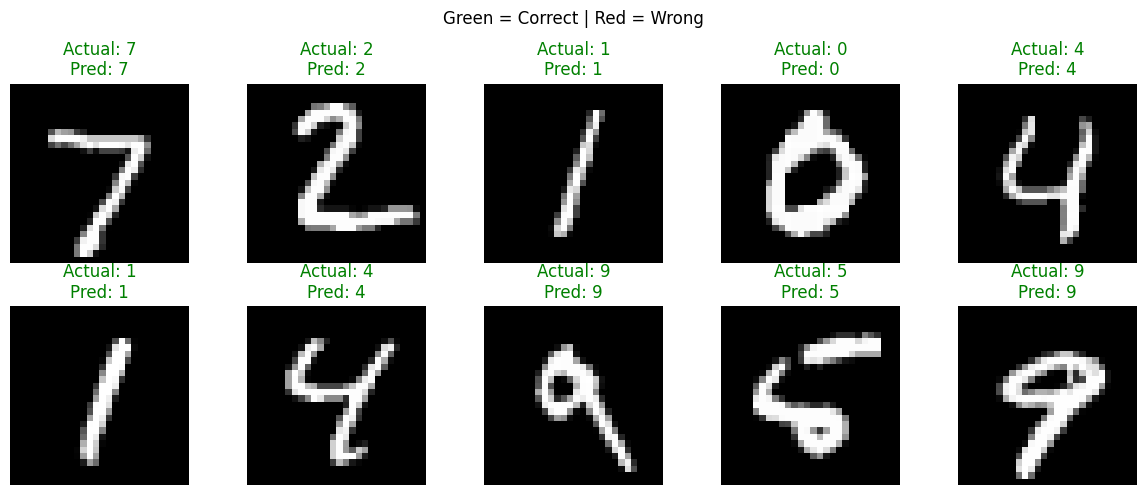

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist 


(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()


X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


X_train_full = X_train_full / 255.0
X_test = X_test / 255.0


X_train = X_train_full[:10000]
y_train = y_train_full[:10000]

print(f"Training samples: {X_train.shape}")
print(f"Testing samples: {X_test.shape}")


k_values = range(1, 10)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())
    print(f"k={k}  accuracy={scores.mean():.4f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\nBest k: {best_k}")


knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
print("Model trained successfully!")


y_pred = knn.predict(X_test)


print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f"Actual: {y_test[i]}\nPred: {y_pred[i]}", color=color)
    ax.axis('off')
plt.suptitle("Green = Correct | Red = Wrong")
plt.tight_layout()
plt.show()